<a href="https://colab.research.google.com/github/192425213simats-a11y/MLA0401---DEEP-LEARNING/blob/main/5.Linear%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

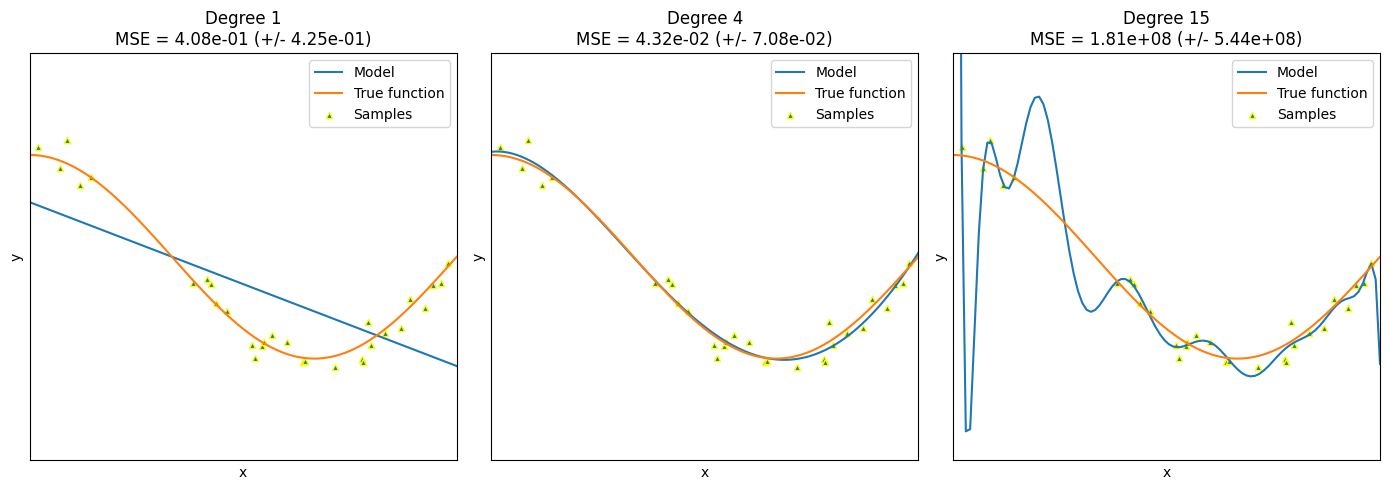

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score


def true_fun(X):
    return np.cos(1.5 * np.pi * X)


# Generate sample data
np.random.seed(0)

n_samples = 30
degrees = [1, 4, 15]

X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

# Create figure
plt.figure(figsize=(14, 5))

for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    # Create polynomial regression pipeline
    polynomial_features = PolynomialFeatures(
        degree=degrees[i],
        include_bias=False
    )

    linear_regression = LinearRegression()

    pipeline = Pipeline([
        ("polynomial_features", polynomial_features),
        ("linear_regression", linear_regression),
    ])

    # Train the model
    pipeline.fit(X[:, np.newaxis], y)

    # Perform 10-fold cross-validation
    scores = cross_val_score(
        pipeline,
        X[:, np.newaxis],
        y,
        scoring="neg_mean_squared_error",
        cv=10
    )

    # Generate test data
    X_test = np.linspace(0, 1, 100)

    # Plot model prediction
    plt.plot(
        X_test,
        pipeline.predict(X_test[:, np.newaxis]),
        label="Model"
    )

    # Plot true function
    plt.plot(
        X_test,
        true_fun(X_test),
        label="True function"
    )

    # Plot training samples
    plt.scatter(
        X,
        y,
        edgecolor="yellow",
        s=20,
        marker="^",
        label="Samples"
    )

    # Labels and title
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")

    plt.title(
        "Degree {}\nMSE = {:.2e} (+/- {:.2e})".format(
            degrees[i],
            -scores.mean(),
            scores.std()
        )
    )

# Display plots
plt.tight_layout()
plt.show()

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  
Mean Squared Error on test set: 0.23


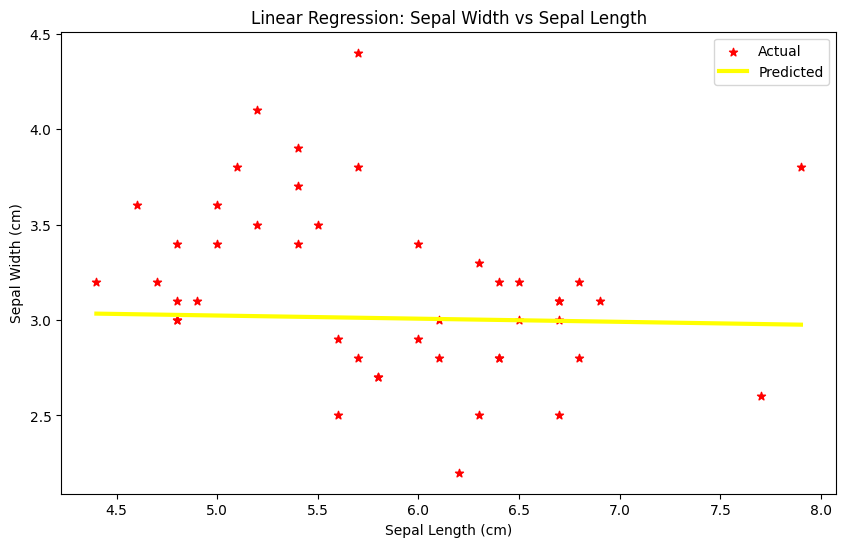

The predicted sepal width for sepal length 5 cm is 3.02 cm


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

iris = load_iris()

data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['species'] = iris.target

print(data.head())

X = data[['sepal length (cm)']]
y = data['sepal width (cm)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on test set: {mse:.2f}")
sorted_indices = X_test.iloc[:, 0].argsort()
X_test_sorted = X_test.iloc[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='red', marker='*', label='Actual')
plt.plot(X_test_sorted, y_pred_sorted, color='yellow', linewidth=3, label='Predicted')

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Linear Regression: Sepal Width vs Sepal Length')
plt.legend()
plt.show()
new_sample = pd.DataFrame([[5]], columns=['sepal length (cm)'])
predicted_width = model.predict(new_sample)
print(
    f"The predicted sepal width for sepal length "
    f"{new_sample.iloc[0, 0]} cm is {predicted_width[0]:.2f} cm"
)